In [ ]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import re

import matplotlib.pyplot as plt

In [ ]:
# Create a directory to save the plots
save_dir = os.path.join(os.getcwd(), '../../results/plots')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Directory created: {save_dir}")
else:
    print(f"Directory already exists: {save_dir}")

# Get today's date for the filenames
today = datetime.now().strftime('%d-%m-%y')

plt.rcParams['pdf.fonttype'] = 'truetype'

# set font to arial globally
plt.rcParams['font.family'] = 'Arial'
# optionally set 'sans-serif' as a backup
plt.rcParams['font.sans-serif'] = ['Arial']

# set global font sizes (adjust as needed)
plt.rcParams.update({ # was 20 
    'font.size': 20,           # controls default text size
    'axes.titlesize': 20,      # fontsize of the axes title
    'axes.labelsize': 20,      # fontsize of the x and y labels
    'xtick.labelsize': 20,     # fontsize of the x tick labels
    'ytick.labelsize': 20,     # fontsize of the y tick labels
    'legend.fontsize': 20,     # fontsize of the legend
    'figure.titlesize': 20     # fontsize of the figure title
})

def create_sort_key(name):
    parts = name.split('_')
    prefix = parts[0].lower()

    # --- extract a/b subtype and give it an order (only affects names like PEN_a_*) ---
    m = re.search(r'_(a|b)_', name, flags=re.IGNORECASE)
    subtype = m.group(1).lower() if m else ''
    subtype_order = {'a': 0, 'b': 1}
    subtype_rank = subtype_order.get(subtype, 99)

    # --- Delta7-only ordering ---
    if prefix == 'delta7':
        l_nums = [int(x) for x in re.findall(r'L(\d+)', name, flags=re.IGNORECASE)]
        r_nums = [int(x) for x in re.findall(r'R(\d+)', name, flags=re.IGNORECASE)]

        l_min = min(l_nums) if l_nums else 0
        l_max = max(l_nums) if l_nums else 0
        r_min = min(r_nums) if r_nums else 0
        r_max = max(r_nums) if r_nums else 0

        # min L asc, then min R desc, then max L asc, then max R asc
        return (prefix, subtype_rank, l_min, -r_min, l_max, r_max)

    # --- default ordering for everything else (your original logic) ---
    r_numbers = []
    l_numbers = []
    for part in parts[1:]:
        r_numbers.extend(int(num) for num in re.findall(r'R(\d+)', part, re.IGNORECASE))
        l_numbers.extend(int(num) for num in re.findall(r'L(\d+)', part, re.IGNORECASE))

    sorted_r = sorted(r_numbers, reverse=True) if r_numbers else [0]
    sorted_l = sorted(l_numbers) if l_numbers else [0]

    return (prefix, subtype_rank, tuple(-num for num in sorted_r), tuple(sorted_l))


er_cells = ['ER_L_MBUv_165041.0', 'ER_R_LAL_47232.0', 'ER_L_MBUv_165261.0',
       'ER_L_MBUv_165035.0', 'ER_R_MBUv_64133.0', 'ER_L_MBUv_65375.0',
       'ER_R_MBUv_47185.0', 'ER_L_MBUv_141300.0', 'ER_L_MBUv_165199.0',
       'ER_R_MBUv_63166.0', 'ER_L_MBUv_165189.0', 'ER_L_MBUv_63018.0',
       'ER_L_MBUv_65369.0', 'ER_L_MBUv_165099.0', 'ER_L_MBUv_165025.0',
       'ER_L_MBUv_64154.0', 'ER_L_MBUv_165291.0', 'ER_R_MBUd_184355.0',
       'ER_L_MBUd_33811.0', 'ER_L_MBUv_165194.0', 'ER_R_MBUd_63046.0',
       'ER_R_MBUv_183953.0', 'ER_R_MBUd_189608.0', 'ER_L_MBUd_165523.0',
       'ER_L_LBU_165560.0', 'ER_L_LBU_62562.0', 'ER_L_MBUd_169326.0',
       'ER_R_MBUd_189306.0', 'ER_L_LBU_142952.0', 'ER_L_LBU_141559.0',
       'ER_L_LBU_139934.0', 'ER_L_MBUd_169538.0', 'ER_L_LBU_143099.0',
       'ER_L_LBU_146249.0', 'ER_L_LBU_141339.0', 'ER_L_LBU_141357.0',
       'ER_L_LBU_142921.0', 'ER_L_LBU_62979.0', 'ER_L_LBU_141367.0',
       'ER_L_LBU_142037.0', 'ER_L_LBU_143094.0', 'ER_L_LBU_188771.0',
       'ER_L_LBU_143024.0', 'ER_L_LBU_148316.0', 'ER_L_LBU_160486.0',
       'ER_L_LBU_62953.0', 'ER_L_LBU_62944.0', 'ER_R_MBUv_184782.0',
       'ER_R_MBUv_189949.0', 'ER_R_MBUv_157781.0', 'ER_R_MBUv_154881.0',
       'ER_R_MBUv_184797.0', 'ER_R_MBUv_184787.0', 'ER_R_MBUv_184329.0',
       'ER_R_MBUv_183928.0', 'ER_R_MBUv_189954.0', 'ER_R_MBUv_184807.0',
       'ER_R_ExR_47226.0']

update_lno_names = {'TN_LNO1_R_SH_AT': 'mLNOa_47215',
'TN_LNO2_R_SH_AT': 'mLNOc_47221',
'TN/LNO3_todo_AT_R_SH':	'mLNOe_56999',
'TN/LNO4_todo_AT_R_SH':	'sLNOb_57016',
'TN/LNO5_todo_AT_R_SH':	'mLNOd_57022',
'TN/LNO6_todo_AT_R_SH':	'sLNOa_57028',
'TN/LNO7_todo_AT_SH':	'mLNOf_57076',
'TN/LNO8_todo_AT_SH':	'sLNOd_57081',
'TN/LNO9_todo_AT_R_SH':	'sLNOc_57628'}

er_df = pd.DataFrame()
er_df['name'] = er_cells

print(f"MBUv n = {len(er_df[er_df['name'].str.contains('MBUv')])}")
print(f"MBUd n = {len(er_df[er_df['name'].str.contains('MBUd')])}")
print(f"LBU n = {len(er_df[er_df['name'].str.contains('LBU')])}")
print(f"LAL n = {len(er_df[er_df['name'].str.contains('LAL')])}")

Directory already exists: D:\Github\codeocean_HD_manuscript\Sayre_et_al_2026_HD\code\analysis\plots
MBUv n = 28
MBUd n = 8
LBU n = 20
LAL n = 1


### figure 1 stacked bar charts

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\avp_cell_counts_17-04-26.pdf


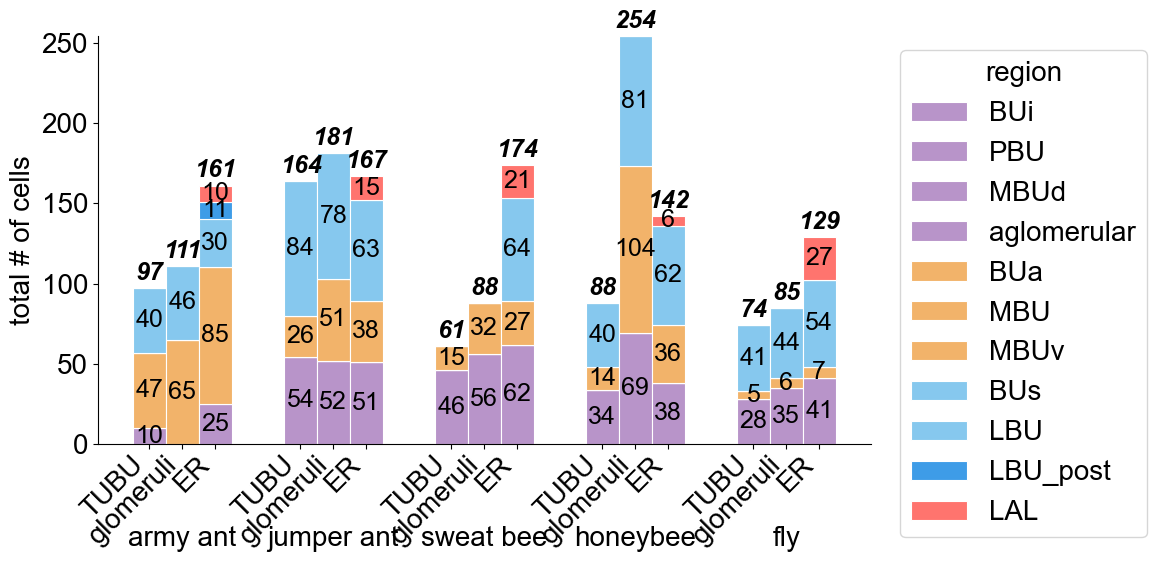

In [ ]:
# Load data
avp_counts = pd.read_csv('../../data/head_direction_cell_counts - AVP_LBUpost.csv')

# Make counts numeric
avp_counts["right_side_count"] = pd.to_numeric(avp_counts["right_side_count"], errors="coerce")
avp_counts["left_side_count"] = pd.to_numeric(avp_counts["left_side_count"], errors="coerce")

# Use the larger of left vs right for each row
avp_counts["count"] = avp_counts[["left_side_count", "right_side_count"]].max(axis=1)

# Keep needed columns
df = avp_counts[["species", "type", "region", "count"]].copy()

# If there are duplicate species-type-region rows, sum them
df = (
    df.groupby(["species", "type", "region"], as_index=False)["count"]
    .sum()
)

# Order of neuron types within each species
type_order = ["TUBU", "glomeruli", "ER"]

species_order = ["army ant", "jumper ant", "sweat bee", "honeybee", "fly"]

# Pivot to wide format: each row = species/type, columns = region
plot_df = df.pivot_table(
    index=["species", "type"],
    columns="region",
    values="count",
    aggfunc="sum",
    fill_value=0
)

# choose region order manually for consistent stack order
roi_order = [
    "BUi", "PBU", "MBUd", "aglomerular",
    "BUa", "MBU", "MBUv",
    "BUs", "LBU", "LBU_post",
    "LAL",
    "other/uncertain"
]

region_order = [r for r in roi_order if r in plot_df.columns]

# Reorder rows
full_index = pd.MultiIndex.from_product(
    [species_order, type_order],
    names=["species", "type"]
)
plot_df = plot_df.reindex(full_index, fill_value=0)

# Reorder columns
plot_df = plot_df.reindex(columns=region_order, fill_value=0)

# ---- plotting ----
n_species = len(species_order)
n_types = len(type_order)
bar_width = 0.22
group_spacing = 0.35

group_centers = np.arange(n_species) * (n_types * bar_width + group_spacing)

fig, ax = plt.subplots(figsize=(12, 6))

# Optional region colors: edit as needed
region_colors = {
    "MBUd": "#b894c9", # purple
    "PBU": "#b894c9",
    "BUa": "#F2B36A",
    "aglomerular": "#b894c9",
    "MBUv": "#F2B36A", # orange
    "MBU": "#F2B36A",
    "BUi": "#b894c9",
    "LBU": "#86C8EE", # blue
    "LBU_post": "#3E9CE7", # blue
    "BUs": "#86C8EE", 
    "LAL": "#FF746E", # red
    "other/uncertain": "#bdbdbd", # grey
}

# fallback if a region is not in the dict
default_color = "#cccccc"


for i, neuron_type in enumerate(type_order):
    x = group_centers + i * bar_width
    sub = plot_df.xs(neuron_type, level="type")
    
    bottom = np.zeros(len(species_order))
    for region in region_order:
        vals = sub[region].values
        
        ax.bar(
            x,
            vals,
            width=bar_width,
            bottom=bottom,
            label=region if i == 0 else None,
            color=region_colors.get(region, default_color),
            edgecolor="white",
            linewidth=0.8
        )
        
        for xi, yi, bi in zip(x, vals, bottom):
            if yi > 0:
                ax.text(
                    xi,
                    bi + yi / 2,
                    f"{int(yi)}",
                    ha="center",
                    va="center",
                    fontsize=18
                )
        
        bottom += vals

    # total label above each full stacked bar
    for xi, total in zip(x, bottom):
        if total > 0:
            ax.text(
                xi,
                total + 2,
                f"{int(total)}",
                ha="center",
                va="bottom",
                fontsize=18,
                fontweight="bold",
                fontstyle="italic"
            )

# x tick labels should be the type labels, repeated for each species
xtick_positions = []
xtick_labels = []

for j, species in enumerate(species_order):
    for i, neuron_type in enumerate(type_order):
        xtick_positions.append(group_centers[j] + i * bar_width)
        xtick_labels.append(neuron_type)

ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45, ha="right")

ax.set_ylabel("total # of cells")

# add species labels below the type labels
ymin, ymax = ax.get_ylim()
species_y = -0.20 * ymax

for j, species in enumerate(species_order):
    species_center = group_centers[j] + bar_width
    ax.text(
        species_center,
        species_y,
        species,
        ha="center",
        va="top",
        fontsize=20
    )

ax.tick_params(axis="x", pad=2)
plt.subplots_adjust(bottom=0.22)

ax.legend(title="region", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

file_path = os.path.join(
    save_dir,
    f"avp_cell_counts_{today}.pdf"
)
plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")

plt.show()

In [5]:
print(avp_counts.columns)

Index(['species', 'region', 'type', 'right_side_count', 'left_side_count',
       'species_total', 'type_total', 'right_side_total', 'left_side_total'],
      dtype='object')


Plot saved: D:\Github\codeocean_HD_manuscript\Sayre_et_al_2026_HD\code\analysis\plots\pen_cell_quantity_02-09-26.pdf


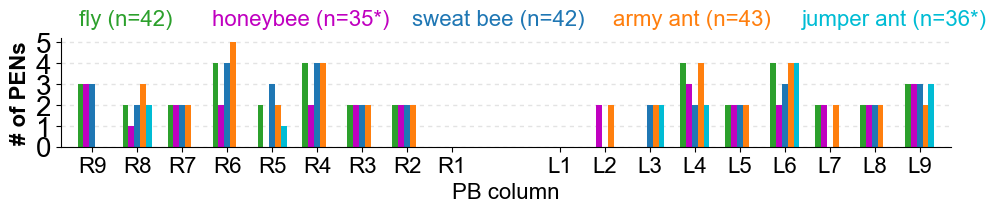

In [4]:
# columnar counts
PB_COLS = ["R9","R8","R7","R6","R5","R4","R3","R2","R1","L1","L2","L3","L4","L5","L6","L7","L8","L9"]

# Species order 
SPECIES = ["fly", "honeybee", "sweat bee", "army ant", "jumper ant"]

COUNTS = {
    "fly":       {"R9":3,"R8":2,"R7":2,"R6":4,"R5":2,"R4":4,"R3":2,"R2":2,"R1":0,"L1":0,"L2":0,"L3":0,"L4":4,"L5":2,"L6":4,"L7":2,"L8":2,"L9":3},
    "honeybee":  {"R9":3,"R8":1,"R7":2,"R6":2,"R5":0,"R4":2,"R3":2,"R2":2,"R1":0,"L1":0,"L2":2,"L3":0,"L4":3,"L5":2,"L6":2,"L7":2,"L8":2,"L9":3},
    "sweat bee": {"R9":3,"R8":2,"R7":2,"R6":4,"R5":3,"R4":4,"R3":2,"R2":2,"R1":0,"L1":0,"L2":0,"L3":2,"L4":2,"L5":2,"L6":3,"L7":0,"L8":2,"L9":3},
    "army ant":  {"R9":0,"R8":3,"R7":2,"R6":5,"R5":2,"R4":4,"R3":2,"R2":2,"R1":0,"L1":0,"L2":2,"L3":2,"L4":4,"L5":2,"L6":4,"L7":2,"L8":2,"L9":2},
    "jumper ant":{"R9":0,"R8":2,"R7":0,"R6":0,"R5":1,"R4":0,"R3":0,"R2":0,"R1":0,"L1":0,"L2":0,"L3":2,"L4":2,"L5":0,"L6":4,"L7":0,"L8":0,"L9":3},
}


rows = []
for sp in SPECIES:
    for col in PB_COLS:
        rows.append({"pb_col": col, "species": sp, "count": COUNTS[sp].get(col, 0)})
df = pd.DataFrame(rows)

##################### 

# Species colors 
COLORS = {
    "fly": "#2ca02c",        # green
    "honeybee": "#c000c0",   # magenta/purple
    "sweat bee": "#1f77b4",  # blue
    "army ant": "#ff7f0e",   # orange
    "jumper ant": "#00bcd4", # cyan-ish
}

TITLE_PARTS = [
    ("fly (n=42)", COLORS["fly"]),
    ("honeybee (n=35*)", COLORS["honeybee"]),
    ("sweat bee (n=42)", COLORS["sweat bee"]),
    ("army ant (n=43)", COLORS["army ant"]),
    ("jumper ant (n=36*)", COLORS["jumper ant"]),
]


# compute x positions (add a visual gap between R-side and L-side)

x = np.arange(len(PB_COLS), dtype=float)

# Create a bigger gap between R1 and L1 like the figure
# (R side indices 0..8, L side indices 9..17)
gap = 1.4
x[9:] += gap

# Bar geometry: thin grouped bars
group_n = len(SPECIES)
bar_w = 0.13
# Center the group on each tick
offsets = (np.arange(group_n) - (group_n - 1) / 2) * bar_w

# plot
fig, ax = plt.subplots(figsize=(10.5, 2.6))

for i, sp in enumerate(SPECIES):
    y = df[df["species"] == sp].set_index("pb_col").loc[PB_COLS, "count"].to_numpy()
    ax.bar(x + offsets[i], y, width=bar_w, color=COLORS[sp], linewidth=0)

# Axes formatting
ax.set_xlim(x.min() - 0.7, x.max() + 0.7)
ax.set_ylim(0, 5.2)
ax.set_yticks(np.arange(0, 6, 1))
ax.set_ylabel("# of PENs", fontsize=16, fontweight="bold")
ax.set_xlabel("PB column", fontsize=16)

ax.set_xticks(x)
ax.set_xticklabels(PB_COLS, fontsize=16)

# Horizontal dashed gridlines like the figure
ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=1, alpha=0.35)
ax.set_axisbelow(True)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# multi-colored title line (manually placed text)

x0 = 0.02
y0 = 1.08
char_scale = 0.0125  # tweak to tighten/loosen spacing between title segments
for text, color in TITLE_PARTS:
    ax.text(x0, y0, text, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=16, color=color)
    x0 += char_scale * (len(text) + 2)

plt.tight_layout()

# Save
fig_name = f"pen_cell_quantity_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")
plt.show()


Plot saved: D:\Github\codeocean_HD_manuscript\Sayre_et_al_2026_HD\code\analysis\plots\epg_cell_quantity_02-09-26.pdf


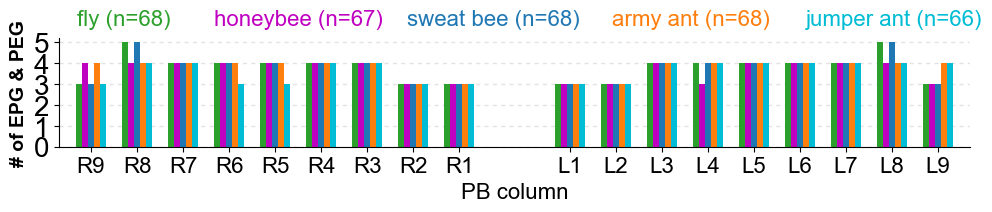

In [5]:
PB_COLS = ["R9","R8","R7","R6","R5","R4","R3","R2","R1","L1","L2","L3","L4","L5","L6","L7","L8","L9"]

# Species order (matches legend/title order in your image)
SPECIES = ["fly", "honeybee", "sweat bee", "army ant", "jumper ant"]

# keep zeros for columns with no bars so spacing matches the figure.

COUNTS = {
    "fly": {
        "R9":3,"R8":5,"R7":4,"R6":4,"R5":4,"R4":4,"R3":4,"R2":3,"R1":3,
        "L1":3,"L2":3,"L3":4,"L4":4,"L5":4,"L6":4,"L7":4,"L8":5,"L9":3
    },
    "honeybee": {
        "R9":4,"R8":4,"R7":4,"R6":4,"R5":4,"R4":4,"R3":4,"R2":3,"R1":3,
        "L1":3,"L2":3,"L3":4,"L4":3,"L5":4,"L6":4,"L7":4,"L8":4,"L9":3
    },
    "sweat bee": {
        "R9":3,"R8":5,"R7":4,"R6":4,"R5":4,"R4":4,"R3":4,"R2":3,"R1":3,
        "L1":3,"L2":3,"L3":4,"L4":4,"L5":4,"L6":4,"L7":4,"L8":5,"L9":3
    },
    "army ant": {
        "R9":4,"R8":4,"R7":4,"R6":4,"R5":4,"R4":4,"R3":4,"R2":3,"R1":3,
        "L1":3,"L2":3,"L3":4,"L4":4,"L5":4,"L6":4,"L7":4,"L8":4,"L9":4
    },
    "jumper ant": {
        "R9":3,"R8":4,"R7":4,"R6":3,"R5":3,"R4":4,"R3":4,"R2":3,"R1":3,
        "L1":3,"L2":3,"L3":4,"L4":4,"L5":4,"L6":4,"L7":4,"L8":4,"L9":4
    },
}


rows = []
for sp in SPECIES:
    for col in PB_COLS:
        rows.append({"pb_col": col, "species": sp, "count": COUNTS[sp].get(col, 0)})
df = pd.DataFrame(rows)

# species colors
COLORS = {
    "fly": "#2ca02c",        # green
    "honeybee": "#c000c0",   # magenta/purple
    "sweat bee": "#1f77b4",  # blue
    "army ant": "#ff7f0e",   # orange
    "jumper ant": "#00bcd4", # cyan-ish
}

TITLE_PARTS = [
    ("fly (n=68)", COLORS["fly"]),
    ("honeybee (n=67)", COLORS["honeybee"]),
    ("sweat bee (n=68)", COLORS["sweat bee"]),
    ("army ant (n=68)", COLORS["army ant"]),
    ("jumper ant (n=66)", COLORS["jumper ant"]),
]

 
# compute x positions (add a gap between R-side and L-side)

x = np.arange(len(PB_COLS), dtype=float)

gap = 1.4
x[9:] += gap

# bar geometry
group_n = len(SPECIES)
bar_w = 0.13
# center the group on each tick
offsets = (np.arange(group_n) - (group_n - 1) / 2) * bar_w

# plot
fig, ax = plt.subplots(figsize=(10.5, 2.6))

for i, sp in enumerate(SPECIES):
    y = df[df["species"] == sp].set_index("pb_col").loc[PB_COLS, "count"].to_numpy()
    ax.bar(x + offsets[i], y, width=bar_w, color=COLORS[sp], linewidth=0)


ax.set_xlim(x.min() - 0.7, x.max() + 0.7)
ax.set_ylim(0, 5.2)
ax.set_yticks(np.arange(0, 6, 1))
ax.set_ylabel("# of EPG & PEG", fontsize=14, fontweight="bold") 

ax.set_xlabel("PB column", fontsize=16)

ax.set_xticks(x)
ax.set_xticklabels(PB_COLS, fontsize=16)


ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=1, alpha=0.35)
ax.set_axisbelow(True)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


x0 = 0.02
y0 = 1.08
char_scale = 0.0125  # tweak to tighten/loosen spacing between title segments
for text, color in TITLE_PARTS:
    ax.text(x0, y0, text, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=16, color=color)
    x0 += char_scale * (len(text) + 2)

plt.tight_layout()

# Save
fig_name = f"epg_cell_quantity_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")
plt.show()


Plot saved: D:\Github\codeocean_HD_manuscript\Sayre_et_al_2026_HD\code\analysis\plots\d7_cell_quantity_02-09-26.pdf


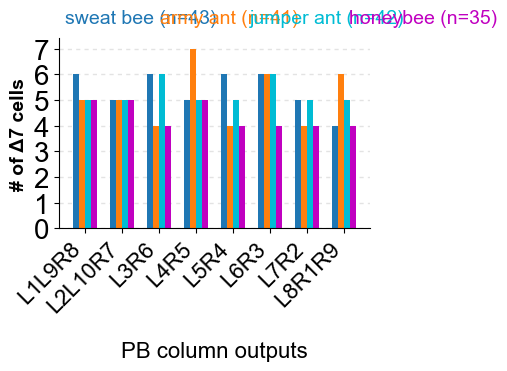

In [6]:
# Δ7 bar plot
X = ["L1L9R8", "L2L10R7", "L3R6", "L4R5", "L5R4", "L6R3", "L7R2", "L8R1R9"]

COUNTS = {
    "sweat bee":  [6, 5, 6, 5, 6, 6, 5, 4],
    "army ant":   [5, 5, 4, 7, 4, 6, 4, 6],
    "jumper ant":[5, 5, 6, 5, 5, 6, 5, 5],
    "honeybee":  [5, 5, 4, 5, 4, 4, 4, 4],
}


COLORS = {
    "honeybee": "#c000c0",   # magenta/purple
    "sweat bee": "#1f77b4",  # blue
    "army ant": "#ff7f0e",   # orange
    "jumper ant": "#00bcd4", # cyan-ish
}

TITLE_PARTS = [
    ("sweat bee (n=43)", COLORS["sweat bee"]),
    ("   ", "black"),
    ("army ant (n=41)", COLORS["army ant"]),
    ("   ", "black"),
    ("jumper ant (n=42)", COLORS["jumper ant"]),
    ("   ", "black"),
    ("honeybee (n=35)", COLORS["honeybee"]),
]

SPECIES = list(COUNTS.keys())

x = np.arange(len(X), dtype=float)
group_n = len(SPECIES)

bar_w = 0.16
offsets = (np.arange(group_n) - (group_n - 1) / 2) * bar_w


fig, ax = plt.subplots(figsize=(5.4, 4.2))

for i, sp in enumerate(SPECIES):
    ax.bar(
        x + offsets[i],
        COUNTS[sp],
        width=bar_w,
        color=COLORS[sp],
        linewidth=0
    )

# Axes
ax.set_ylim(0, 7.4)
ax.set_yticks(np.arange(0, 8, 1))
ax.set_ylabel("# of Δ7 cells", fontsize=14, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(X, rotation=45, ha="right", fontsize=16)

ax.set_xlabel("PB column outputs", fontsize=16, labelpad=18)

# Gridlines
ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=1, alpha=0.35)
ax.set_axisbelow(True)

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


x0 = 0.02
y0 = 1.06
char_scale = 0.016

for text, color in TITLE_PARTS:
    ax.text(
        x0, y0, text,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=14,
        color=color
    )
    x0 += char_scale * len(text)

plt.tight_layout()

# Save
fig_name = f"d7_cell_quantity_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")
plt.show()
